### RAG vs Fine tuning

Retrieval-Augmented Generation (RAG) and Fine-Tuning are two widely used approaches for adapting large language models to specific tasks or domains. Although both techniques improve model performance for specialized applications, they differ significantly in methodology, cost, maintenance, and use cases.

**RAG** is a technique that combines a large language model with an external knowledge source. Instead of storing new information inside the model's parameters, the system retrieves relevant documents from a knowledge base and provides them to the model as additional context during inference.

**Fine-tuning** is the process of training a pre-trained language model on a specific dataset to adapt its behavior, knowledge, or style to a particular task or domain.


| Dimension | RAG | Fine-Tuning |
|---|---|---|
| Knowledge updates | Easy — update the database | Requires retraining |
| Hardware | Minimal | Requires GPUs |
| Hallucination | Reduced (grounded in docs) | Can still hallucinate |
| Consistency | Depends on retrieval | More consistent |
| Best for | Chatbots, Q&A, enterprise search | Classification, summarization, domain assistants |

Prepare a model for training with a PEFT method such as LoRA by wrapping the base model and PEFT configuration
with get_peft_model . For the bigscience/mt0-large model, you're only training 0.19% of the parameters!

In [5]:
%pip install peft

In [6]:
!pip install "torchao>=0.16.0"

#### Pretrained Model

Training a model from scratch requires:
- huge datasets
- expensive GPUs
- weeks or months

Instead, researchers train a model once.
That model is called a pretrained model.
Examples include:

- MT0
- T5
- BERT

These models already understand language.

### FineTuning

Fine-tuning a Large Language Model (LLM) means continuing the training of a pre-trained base model on a smaller, task-specific dataset so the model adapts to your domain, style, or task requirements.

#### The Problem with Fine-Tuning

Imagine a model with: 1B parameters

Training all of them means:

- lots of GPU memory
- slow training
- huge storage requirements

For large models this becomes very expensive.


### PEFT

Parameter Efficient Fine-Tuning.

The idea:

Instead of training billions of parameters,train only a small number.

Methods include:
LoRA
Prefix Tuning
Prompt Tuning
Adapters

#### LoRA is one of the most important techniques that makes fine-tuning large models practical on limited hardware.

1. Load a pretrained model.
2. Freeze most of its parameters.
3. Add small trainable adapters.
4. Train only those adapters.
5. Save memory and computation.

In [7]:
from transformers import AutoModelForSeq2SeqLM
from peft import  get_peft_config, get_peft_model, LoraConfig, TaskType

model_name_or_path="bigscience/mt0-large"
tokenizer_name_or_path="bigscience/mt0-large"

peft_config=LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM, inference_mode=False,r=8,lora_alpha=32, lora_dropout=0.1

)

model=AutoModelForSeq2SeqLM.from_pretrained(model_name_or_path)
model=get_peft_model(model,peft_config)
model.print_trainable_parameters()
"trainable params: 2359296 || all params: 1231940608 || trainable%: 0.19151053100118282"

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 2,359,296 || all params: 1,231,940,608 || trainable%: 0.1915


'trainable params: 2359296 || all params: 1231940608 || trainable%: 0.19151053100118282'

### Quantization

Quantization in machine learning (especially for LLMs and deep learning models) refers to the process of reducing the precision of numbers used to represent model parameters (weights, activations). Instead of storing them as 32‑bit floating point (float32), we use lower precision formats like 16‑bit (float16), 8‑bit (int8), or even 4‑bit

#### int-8 Quantization


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate original float values (e.g model weights)
x=np.linspace(-1.0,1.0,100)
x[:10]

array([-1.        , -0.97979798, -0.95959596, -0.93939394, -0.91919192,
       -0.8989899 , -0.87878788, -0.85858586, -0.83838384, -0.81818182])

In [15]:
#define quantization parameters

min_x = -1.0
max_x=1.0
qmin=-128
qmax=127

#calculate scale and zero point for symmetric quantization
scale= (max_x-min_x) / (qmax-qmin) # step size
scale

0.00784313725490196

In [ ]:
zero_point=0

#Quantization :float ->int8
q=np.round((x-zero_point)/scale).astype(int)

q=np.clip(q,qmin,qmax)
q[:10]

In [16]:
# Dequantization:int8 ->float
x_hat=scale*(q - zero_point)
x_hat[:10]

array([-1.00392157, -0.98039216, -0.95686275, -0.94117647, -0.91764706,
       -0.90196078, -0.87843137, -0.85490196, -0.83921569, -0.81568627])

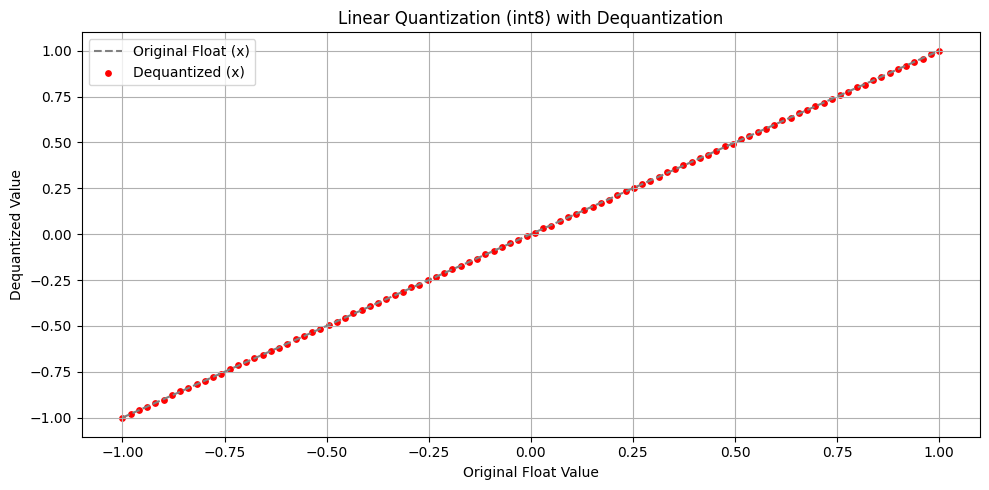

In [18]:
# plot original vs dequantized
plt.figure(figsize=(10, 5))
plt.plot(x, x, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(x, x_hat, label='Dequantized (x)', color='red', s=15)
plt.title('Linear Quantization (int8) with Dequantization')
plt.xlabel('Original Float Value')
plt.ylabel('Dequantized Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### QLoRA

QLoRA is a memory-efficient fine-tuning method
that combines 4-bit quantization (compressing
model weights) with Low-Rank Adaptation (LoRA)
(training small adapter matrices).

It uses NF4 quantization, Double Quantization and also a concept "Paged Optimizers"

We can finetune a 65B parameter model on a single 48GB GPU while
preserving full 16-bit finetuning task performance.

#### NF4 means Normal Float 4.

It was introduced in the original QLoRA paper because it preserves model quality better than ordinary 4-bit integers.

#### Double Quantization
```
bnb_4bit_use_double_quant=True
```
This further compresses the quantization constants.

In [19]:
!pip install transformers peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00


In [20]:
import torch
from transformers import AutoModelForSeq2SeqLM,AutoTokenizer,BitsAndBytesConfig
from peft import LoraConfig,get_peft_model,TaskType

model_name = "bigscience/mt0-large"

# 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# load quantized model
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

# LoRA configuration
peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    inference_mode=False,
)

# add LoRA adapters
model = get_peft_model(model, peft_config)

model.print_trainable_parameters()

tokenizer_config.json:   0%|          | 0.00/430 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 2,359,296 || all params: 1,231,940,608 || trainable%: 0.1915
